# 01 — Exploratory Data Analysis and Cleaning

## Santander Customer Satisfaction

**Goal:** Understand the data before building any model.  
**Output:** `pickles/train_eda.pkl` and `pickles/test_eda.pkl` — cleaned and ready for Feature Engineering.

### What we cover:
1. Data shape and types
2. Target variable — understanding the imbalance
3. Missing values
4. Feature groups — what columns exist
5. Sparsity analysis — how many zeros
6. Key feature distributions
7. Correlation with TARGET
8. Findings summary

## 1. Imports and Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Plot styling
sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

# Paths — adjust if your folder is different
TRAIN_PATH = '../data/raw/train.csv'
TEST_PATH  = '../data/raw/test.csv'
PICKLE_DIR = '../pickles/'

os.makedirs(PICKLE_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 2. Load Data

In [2]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Train shape : {train.shape}')  # expect (76020, 371)
print(f'Test shape  : {test.shape}')   # expect (75818, 370)
print(f'\nTrain columns: {list(train.columns[:5])} ... {list(train.columns[-3:])}')
print(f'Test columns : {list(test.columns[:5])} ... {list(test.columns[-3:])}')

Train shape : (76020, 371)
Test shape  : (75818, 370)

Train columns: ['ID', 'var3', 'var15', 'imp_ent_var16_ult1', 'imp_op_var39_comer_ult1'] ... ['saldo_medio_var44_ult3', 'var38', 'TARGET']
Test columns : ['ID', 'var3', 'var15', 'imp_ent_var16_ult1', 'imp_op_var39_comer_ult1'] ... ['saldo_medio_var44_ult1', 'saldo_medio_var44_ult3', 'var38']


In [3]:
# Quick peek at data
train.head(3)

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.17,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.03,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.77,0


## 3. Data Types and Memory

In [4]:
print('=== Data Types ===')
print(train.dtypes.value_counts())

print(f'\n=== Memory Usage ===')
mem_mb = train.memory_usage(deep=True).sum() / 1024**2
print(f'Train dataframe: {mem_mb:.1f} MB')

# Key insight: all columns are numeric (int64 or float64)
# No text columns, no dates — purely numerical data
print('\nAll features are numeric — no text encoding needed.')

=== Data Types ===
int64      260
float64    111
Name: count, dtype: int64

=== Memory Usage ===
Train dataframe: 215.2 MB

All features are numeric — no text encoding needed.


## 4. Missing Values

In [5]:
train_missing = train.isnull().sum().sum()
test_missing  = test.isnull().sum().sum()

print(f'Missing values in train : {train_missing}')
print(f'Missing values in test  : {test_missing}')

# var3 has a sentinel value -999999 which acts as a hidden missing value
print(f'\nvar3 unique values (sample): {sorted(train["var3"].unique())[:10]}')
print(f'var3 value -999999 count   : {(train["var3"] == -999999).sum()}')
print('\n→ -999999 in var3 is a hidden missing value. Will fix in Feature Engineering.')

Missing values in train : 0
Missing values in test  : 0

var3 unique values (sample): [-999999, 0, 1, 2, 3, 4, 5, 6, 7, 8]
var3 value -999999 count   : 116

→ -999999 in var3 is a hidden missing value. Will fix in Feature Engineering.


## 5. Target Variable — The Imbalance Problem

This is the most important thing to understand about this dataset.  
The target is highly imbalanced — very few dissatisfied customers.

In [6]:
target_counts = train['TARGET'].value_counts()
target_pct    = train['TARGET'].value_counts(normalize=True) * 100

print('=== Target Distribution ===')
print(f'Satisfied customers   (0): {target_counts[0]:,}  ({target_pct[0]:.2f}%)')
print(f'Dissatisfied customers(1): {target_counts[1]:,}  ({target_pct[1]:.2f}%)')
print(f'\nImbalance ratio: {target_counts[0]/target_counts[1]:.0f}:1')
print('\n→ For every 1 unhappy customer there are ~24 happy customers.')
print('→ This is why we use AUC, not accuracy.')
print('→ A model predicting everyone=0 gets 96% accuracy but AUC=0.5 (useless).')

=== Target Distribution ===
Satisfied customers   (0): 73,012  (96.04%)
Dissatisfied customers(1): 3,008  (3.96%)

Imbalance ratio: 24:1

→ For every 1 unhappy customer there are ~24 happy customers.
→ This is why we use AUC, not accuracy.
→ A model predicting everyone=0 gets 96% accuracy but AUC=0.5 (useless).


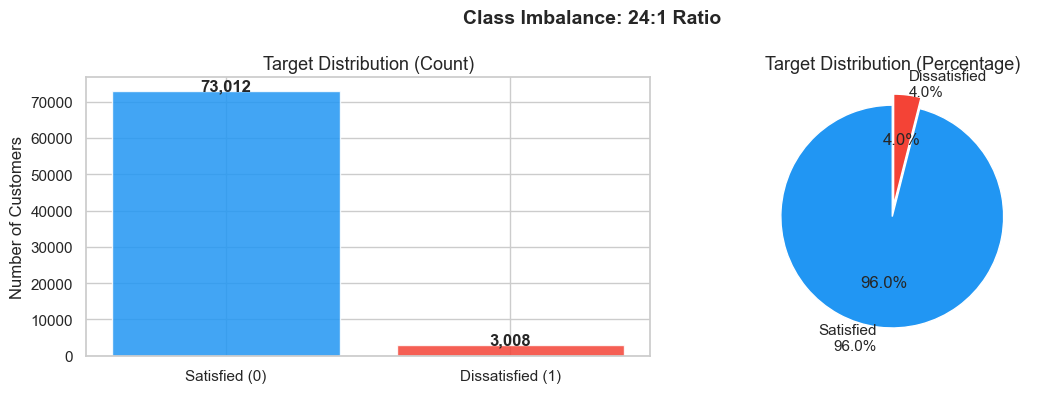

Key insight: 96% satisfied, 4% dissatisfied — severe imbalance


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Satisfied (0)', 'Dissatisfied (1)'], 
            [target_counts[0], target_counts[1]],
            color=['#2196F3', '#F44336'], alpha=0.85, edgecolor='white')
axes[0].set_title('Target Distribution (Count)')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate([target_counts[0], target_counts[1]]):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Percentage pie
axes[1].pie([target_pct[0], target_pct[1]], 
            labels=[f'Satisfied\n{target_pct[0]:.1f}%', f'Dissatisfied\n{target_pct[1]:.1f}%'],
            colors=['#2196F3', '#F44336'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Target Distribution (Percentage)')

plt.suptitle('Class Imbalance: 24:1 Ratio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../pickles/target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Key insight: 96% satisfied, 4% dissatisfied — severe imbalance')

## 6. Feature Groups

Even though features are anonymous, their **names follow patterns**.  
This helps us understand what type of data each group contains.

In [10]:
feature_cols = [c for c in train.columns if c not in ['ID', 'TARGET']]

groups = {
    'saldo' : [c for c in feature_cols if 'saldo' in c],   # balance features
    'imp'   : [c for c in feature_cols if 'imp' in c],     # amount/import features  
    'num'   : [c for c in feature_cols if c.startswith('num')],  # count features
    'ind'   : [c for c in feature_cols if c.startswith('ind')],  # indicator features
    'delta' : [c for c in feature_cols if 'delta' in c],   # change/delta features
    'var'   : [c for c in feature_cols if c.startswith('var')],  # generic variables
}

print('=== Feature Groups ===')
print(f'{"Group":<10} {"Count":<8} {"What it likely means"}')
print('-' * 55)
meanings = {
    'saldo' : 'Account balances',
    'imp'   : 'Transaction amounts',
    'num'   : 'Transaction counts',
    'ind'   : 'Binary indicators (0/1)',
    'delta' : 'Changes over time',
    'var'   : 'Generic variables (inc. demographics)',
}
total = 0
for g, cols in groups.items():
    print(f'{g:<10} {len(cols):<8} {meanings[g]}')
    total += len(cols)
print('-' * 55)
print(f'{"TOTAL":<10} {total}')

=== Feature Groups ===
Group      Count    What it likely means
-------------------------------------------------------
saldo      71       Account balances
imp        63       Transaction amounts
num        143      Transaction counts
ind        75       Binary indicators (0/1)
delta      26       Changes over time
var        5        Generic variables (inc. demographics)
-------------------------------------------------------
TOTAL      383


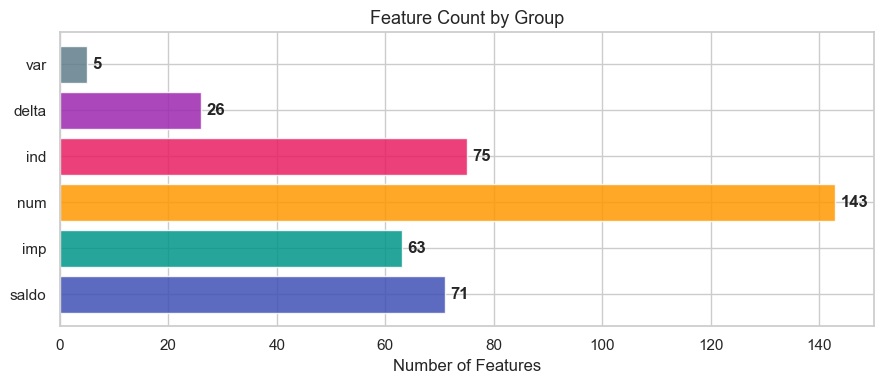

In [11]:
# Visualize group sizes
fig, ax = plt.subplots(figsize=(9, 4))
group_names = list(groups.keys())
group_sizes = [len(groups[g]) for g in group_names]
colors = ['#3F51B5','#009688','#FF9800','#E91E63','#9C27B0','#607D8B']

bars = ax.barh(group_names, group_sizes, color=colors, alpha=0.85, edgecolor='white')
for bar, size in zip(bars, group_sizes):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(size), va='center', fontweight='bold')

ax.set_xlabel('Number of Features')
ax.set_title('Feature Count by Group')
plt.tight_layout()
plt.savefig('../pickles/feature_groups.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Sparsity Analysis

**Sparsity** means most values in the dataset are zero.  
This is very common in banking data — most customers don't use every product.

In [13]:
# Overall sparsity
overall_zero_pct = (train[feature_cols] == 0).sum().sum() / (len(feature_cols) * len(train))
print(f'Overall zero percentage across all features: {overall_zero_pct:.1%}')
print(f'→ About 9 out of 10 values in this dataset are zero!')

# Per-row sparsity: how many zeros does each customer have?
train['num_zeros']    = (train[feature_cols] == 0).sum(axis=1)
train['num_nonzeros'] = (train[feature_cols] != 0).sum(axis=1)

print(f'\nAverage zeros per customer   : {train["num_zeros"].mean():.0f} / {len(feature_cols)}')
print(f'Average non-zeros per customer: {train["num_nonzeros"].mean():.0f} / {len(feature_cols)}')

Overall zero percentage across all features: 90.9%
→ About 9 out of 10 values in this dataset are zero!

Average zeros per customer   : 335 / 369
Average non-zeros per customer: 34 / 369


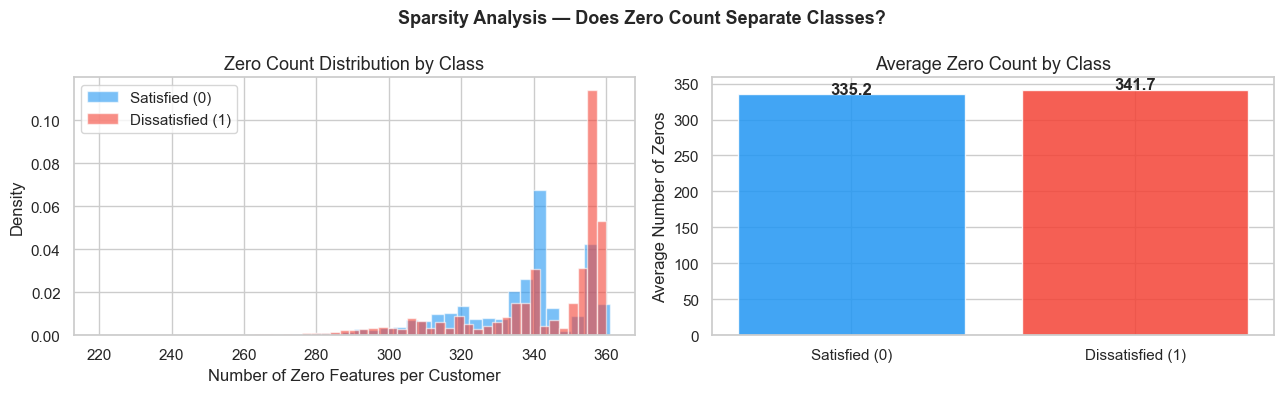

Mean zeros — Satisfied    : 335.2
Mean zeros — Dissatisfied : 341.7
→ If these differ significantly, num_zeros is a useful feature!


In [14]:
# Does sparsity differ between satisfied and dissatisfied customers?
# This tells us if num_zeros is a useful feature

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Zeros distribution by class
for target_val, color, label in [(0, '#2196F3', 'Satisfied (0)'), 
                                   (1, '#F44336', 'Dissatisfied (1)')]:
    subset = train[train['TARGET'] == target_val]['num_zeros']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)

axes[0].set_title('Zero Count Distribution by Class')
axes[0].set_xlabel('Number of Zero Features per Customer')
axes[0].set_ylabel('Density')
axes[0].legend()

# Mean zeros by class
mean_zeros = train.groupby('TARGET')['num_zeros'].mean()
axes[1].bar(['Satisfied (0)', 'Dissatisfied (1)'], 
            mean_zeros.values,
            color=['#2196F3', '#F44336'], alpha=0.85, edgecolor='white')
axes[1].set_title('Average Zero Count by Class')
axes[1].set_ylabel('Average Number of Zeros')
for i, v in enumerate(mean_zeros.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('Sparsity Analysis — Does Zero Count Separate Classes?', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../pickles/sparsity_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mean zeros — Satisfied    : {mean_zeros[0]:.1f}')
print(f'Mean zeros — Dissatisfied : {mean_zeros[1]:.1f}')
print('→ If these differ significantly, num_zeros is a useful feature!')

## 8. Key Individual Features

`var15` is known to be customer age.  
`var38` is likely account value/loan amount — the most important single feature.

In [15]:
# var15 — likely customer age
print('=== var15 (likely Age) ===')
print(train['var15'].describe())
print(f'\nUnder 23 years old: {(train["var15"] < 23).sum()} customers')
print('→ Customers under 23 behave differently — we will create a binary feature for this')

=== var15 (likely Age) ===
count    76020.000000
mean        33.212865
std         12.956486
min          5.000000
25%         23.000000
50%         28.000000
75%         40.000000
max        105.000000
Name: var15, dtype: float64

Under 23 years old: 1212 customers
→ Customers under 23 behave differently — we will create a binary feature for this


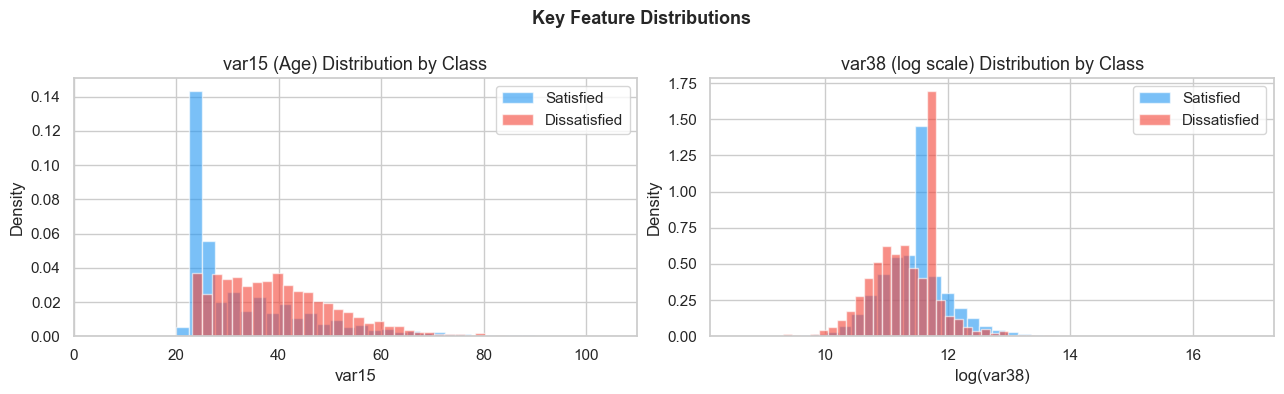

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# var15 by target
for target_val, color, label in [(0, '#2196F3', 'Satisfied'), 
                                   (1, '#F44336', 'Dissatisfied')]:
    subset = train[train['TARGET'] == target_val]['var15']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
axes[0].set_title('var15 (Age) Distribution by Class')
axes[0].set_xlabel('var15')
axes[0].set_ylabel('Density')
axes[0].legend()

# var38 — log scale because values are very large
for target_val, color, label in [(0, '#2196F3', 'Satisfied'), 
                                   (1, '#F44336', 'Dissatisfied')]:
    subset = np.log1p(train[train['TARGET'] == target_val]['var38'])
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
axes[1].set_title('var38 (log scale) Distribution by Class')
axes[1].set_xlabel('log(var38)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Key Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../pickles/key_features.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Zero Variance and Sparse Features

Before looking at correlations, we remove useless features.  
This makes the correlation analysis cleaner and faster.

In [17]:
feature_cols = [c for c in train.columns if c not in ['ID', 'TARGET', 
                                                        'num_zeros', 'num_nonzeros']]

# Zero variance — these carry zero information
zero_var = [c for c in feature_cols if train[c].var() == 0]
print(f'Zero variance features : {len(zero_var)}')
print(f'Example               : {zero_var[:5]}')

# Sparse — 99th percentile is 0, meaning 99%+ of values are zero
sparse = [c for c in feature_cols if np.percentile(train[c], 99) == 0]
print(f'\nSparse features (99th pct = 0): {len(sparse)}')

# Combined
useless = list(set(zero_var + sparse))
useful  = [c for c in feature_cols if c not in useless]
print(f'\nTotal useless features to drop : {len(useless)}')
print(f'Remaining useful features      : {len(useful)}')
print(f'\n→ We go from {len(feature_cols)} → {len(useful)} features just from this step!')

Zero variance features : 34
Example               : ['ind_var2_0', 'ind_var2', 'ind_var27_0', 'ind_var28_0', 'ind_var28']

Sparse features (99th pct = 0): 222

Total useless features to drop : 222
Remaining useful features      : 147

→ We go from 369 → 147 features just from this step!


## 10. Correlation with TARGET

In [20]:
# Compute correlation of remaining features with TARGET
correlations = train[useful + ['TARGET']].corr()['TARGET'].drop('TARGET')
correlations = correlations.sort_values(key=abs, ascending=False)

print('=== Top 20 features most correlated with TARGET ===')
print(correlations.head(20).to_string())
print(f'\nvar38 correlation: {correlations.get("var38", "not in useful set"):.4f}')

=== Top 20 features most correlated with TARGET ===
ind_var30             -0.149811
num_meses_var5_ult3   -0.148253
num_var30             -0.138289
num_var42             -0.135693
ind_var5              -0.135349
num_var5              -0.134095
var36                  0.102919
var15                  0.101322
num_var4              -0.080194
num_var35             -0.076872
ind_var8_0             0.046665
num_var8_0             0.046622
ind_var13             -0.039612
ind_var13_0           -0.039471
num_var13             -0.038400
ind_var12_0           -0.038215
num_var13_0           -0.038045
saldo_var30           -0.037092
ind_var39_0           -0.035045
ind_var13_corto       -0.034438

var38 correlation: -0.0195


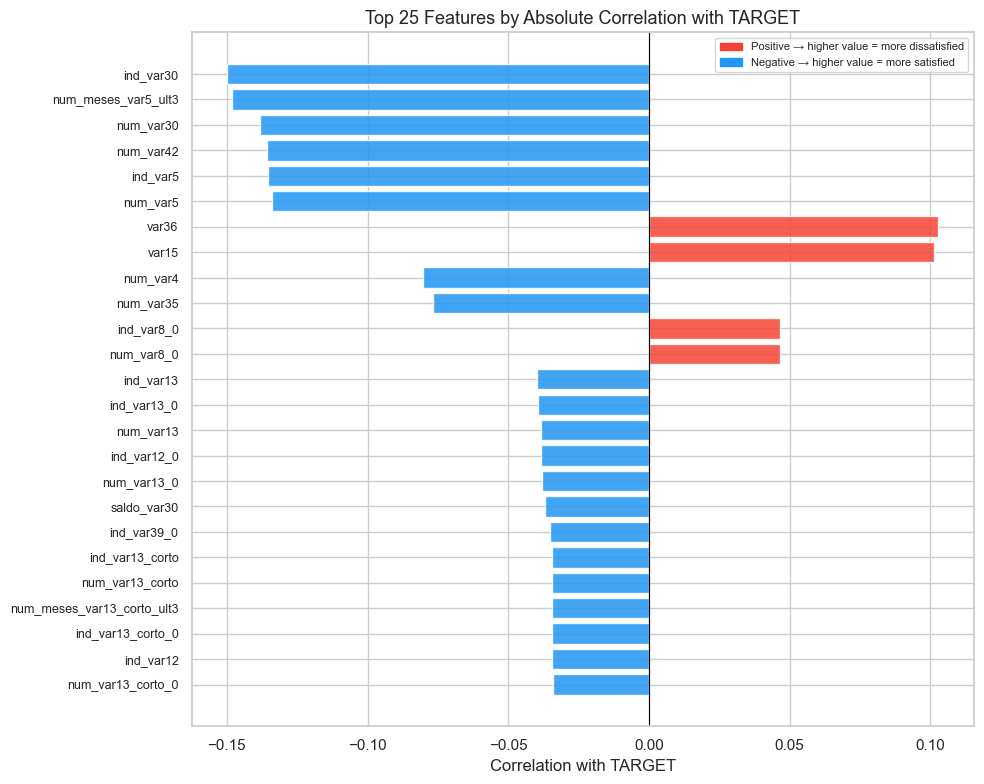

In [21]:
# Plot top 25 correlated features
top25 = correlations.head(25)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#F44336' if v > 0 else '#2196F3' for v in top25.values]
ax.barh(range(len(top25)), top25.values, color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with TARGET')
ax.set_title('Top 25 Features by Absolute Correlation with TARGET')
ax.invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend = [Patch(color='#F44336', label='Positive → higher value = more dissatisfied'),
          Patch(color='#2196F3', label='Negative → higher value = more satisfied')]
ax.legend(handles=legend, fontsize=8)

plt.tight_layout()
plt.savefig('../pickles/correlations.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Train vs Test Distribution Check

We need train and test to have similar distributions.  
If they don't, our model won't generalize.

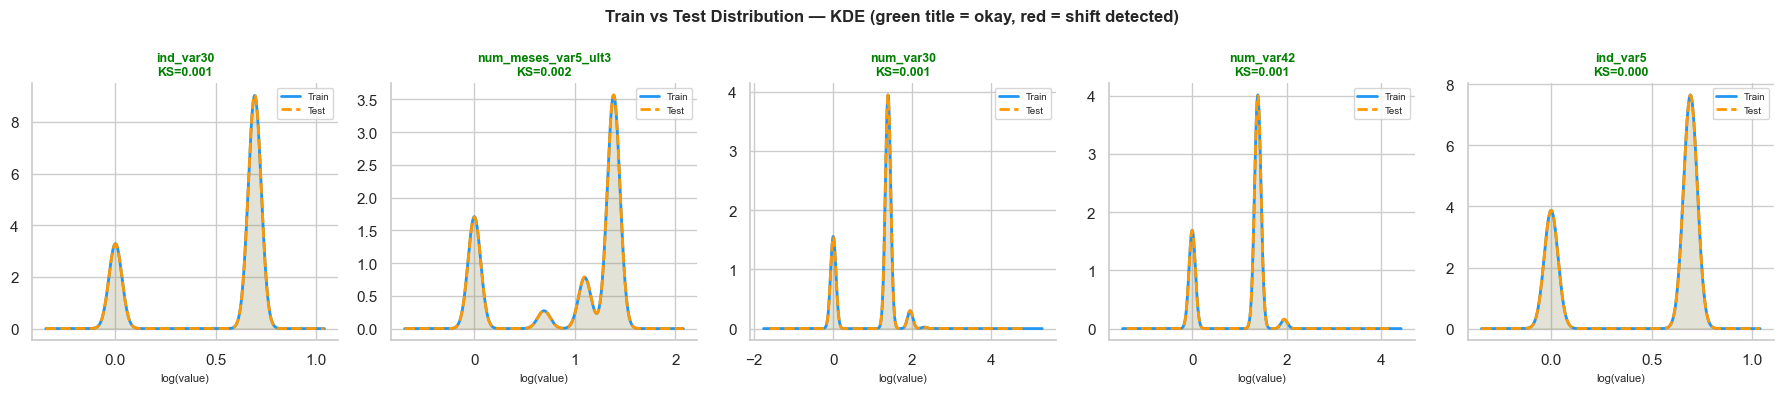

In [28]:
from scipy import stats

top5_features = list(correlations.head(5).index)
valid_features = [c for c in top5_features if c in test.columns]

fig, axes = plt.subplots(1, len(valid_features), figsize=(18, 4))

for i, col in enumerate(valid_features):
    ax = axes[i]
    
    train_vals = np.log1p(train[col].clip(lower=0))
    test_vals  = np.log1p(test[col].clip(lower=0))
    
    # KDE curves — smooth lines instead of jagged bars
    train_vals.plot.kde(ax=ax, label='Train', color='#2196F3', linewidth=2)
    test_vals.plot.kde(ax=ax,  label='Test',  color='#FF9800', linewidth=2, linestyle='--')
    
    # Fill under curves for easy visual comparison
    ax.fill_between(ax.lines[0].get_xdata(), ax.lines[0].get_ydata(), alpha=0.15, color='#2196F3')
    ax.fill_between(ax.lines[1].get_xdata(), ax.lines[1].get_ydata(), alpha=0.15, color='#FF9800')
    
    # KS test — tells you statistically how different the distributions are
    ks_stat, p_val = stats.ks_2samp(train[col].dropna(), test[col].dropna())
    
    # Color the title red if distributions differ significantly
    title_color = 'red' if ks_stat > 0.1 else 'green'
    ax.set_title(f'{col}\nKS={ks_stat:.3f}', fontsize=9, color=title_color, fontweight='bold')
    ax.set_xlabel('log(value)', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_ylabel('')
    
    # Shade the "gap" area between curves to highlight shift
    sns.despine(ax=ax)

plt.suptitle('Train vs Test Distribution — KDE (green title = okay, red = shift detected)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../pickles/train_test_dist.png', dpi=120, bbox_inches='tight')
plt.show()


## 12. EDA Summary — Key Findings

Everything your model and feature engineering decisions should be based on.

In [29]:
print('=' * 60)
print('EDA SUMMARY — KEY FINDINGS')
print('=' * 60)

print('''
1. IMBALANCE
   - 96% satisfied, 4% dissatisfied (~24:1 ratio)
   - Must use: scale_pos_weight=24 in XGBoost
   - Must use: AUC as metric, NOT accuracy

2. MISSING VALUES
   - No actual NaN values
   - var3 has -999999 as hidden missing → replace with mode

3. SPARSITY
   - ~90% of all values are zero
   - num_zeros per row is a useful engineered feature
   - Group-level zero counts (saldo, imp, num) also useful

4. USELESS FEATURES
   - Zero variance features: drop immediately
   - Sparse features (99th pct=0): drop
   - Goes from 370 → ~142 features after cleanup

5. KEY FEATURES
   - var38 (account value): strongest single predictor
   - var15 (age): create under-23 binary + age bins
   - saldo and imp groups: apply log transform (highly skewed)

6. FEATURE ENGINEERING PLAN
   - Fix var3 sentinel
   - Add num_zeros (overall + per group)
   - Log transform saldo + imp features
   - Bin var15 into age groups
   - Remove low correlation + high inter-correlation features
   - Select top 250 by XGBoost importance
''')
print('=' * 60)

EDA SUMMARY — KEY FINDINGS

1. IMBALANCE
   - 96% satisfied, 4% dissatisfied (~24:1 ratio)
   - Must use: scale_pos_weight=24 in XGBoost
   - Must use: AUC as metric, NOT accuracy

2. MISSING VALUES
   - No actual NaN values
   - var3 has -999999 as hidden missing → replace with mode

3. SPARSITY
   - ~90% of all values are zero
   - num_zeros per row is a useful engineered feature
   - Group-level zero counts (saldo, imp, num) also useful

4. USELESS FEATURES
   - Zero variance features: drop immediately
   - Sparse features (99th pct=0): drop
   - Goes from 370 → ~142 features after cleanup

5. KEY FEATURES
   - var38 (account value): strongest single predictor
   - var15 (age): create under-23 binary + age bins
   - saldo and imp groups: apply log transform (highly skewed)

6. FEATURE ENGINEERING PLAN
   - Fix var3 sentinel
   - Add num_zeros (overall + per group)
   - Log transform saldo + imp features
   - Bin var15 into age groups
   - Remove low correlation + high inter-correlat

## 13. Save Outputs for Feature Engineering

Drop the temporary EDA columns and save clean pickles.

In [30]:
# Drop the temporary columns we added during EDA
train.drop(columns=['num_zeros', 'num_nonzeros'], inplace=True, errors='ignore')

# Save — these are the raw files, just verified clean
train.to_pickle(f'{PICKLE_DIR}train_eda.pkl')
test.to_pickle(f'{PICKLE_DIR}test_eda.pkl')

print(f'Saved: {PICKLE_DIR}train_eda.pkl  →  shape {train.shape}')
print(f'Saved: {PICKLE_DIR}test_eda.pkl   →  shape {test.shape}')
print('\n✅ EDA complete. Next: 02_Feature_Engineering.ipynb')

Saved: ../pickles/train_eda.pkl  →  shape (76020, 371)
Saved: ../pickles/test_eda.pkl   →  shape (75818, 370)

✅ EDA complete. Next: 02_Feature_Engineering.ipynb
